<a href="https://colab.research.google.com/github/jennifer-algabre/flyrank-ml-internship/blob/main/work/notebooks/w04_signal_audit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-06 — Signal Audit: Do the Flags Hold?

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [15]:
!git clone https://github.com/jennifer-algabre/flyrank-ml-internship.git
%cd flyrank-ml-internship

Cloning into 'flyrank-ml-internship'...
remote: Enumerating objects: 138, done.
remote: Counting objects: 100% (138/138), done.
remote: Compressing objects: 100% (109/109), done.
remote: Total 138 (delta 51), reused 78 (delta 13), pack-reused 0 (from 0)
Receiving objects: 100% (138/138), 1.86 MiB | 6.62 MiB/s, done.
Resolving deltas: 100% (51/51), done.
/content/flyrank-ml-internship/flyrank-ml-internship/flyrank-ml-internship


In [17]:
!find . -name "*.csv"

./outputs/refresh_queue_sample.csv
./data/raw/content_refresh_anonymized.csv
./outputs/refresh_queue_sample.csv
./data/raw/content_refresh_anonymized.csv


## 1. Distributions

*Look before deciding: distributions of your key fields. Note the heavy tails.*

Before evaluating individual signals, I inspected the distributions of the key variables used in this lane. This helps identify whether the variables are balanced or have heavy-tailed distributions that could influence simple rule-based decisions.

       impressions_90d           ctr  content_age_days  days_since_last_update
count     30000.000000  30000.000000       30000.00000            30000.000000
mean       5200.366300      0.510733         256.16780               46.098300
std       16838.019547      3.279162         132.70793               42.078709
min           1.000000      0.000000          90.00000                1.000000
25%          81.000000      0.000000         132.00000               20.000000
50%         731.000000      0.070000         236.00000               20.000000
75%        3615.250000      0.290000         333.00000              104.000000
max      517715.000000    100.000000         564.00000              373.000000


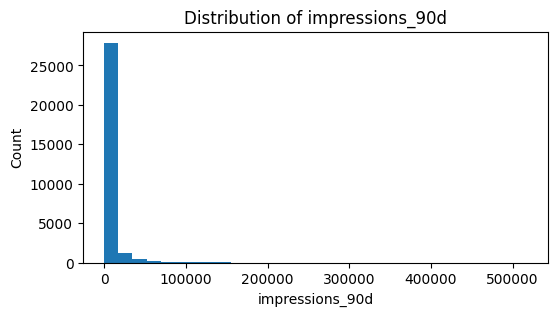

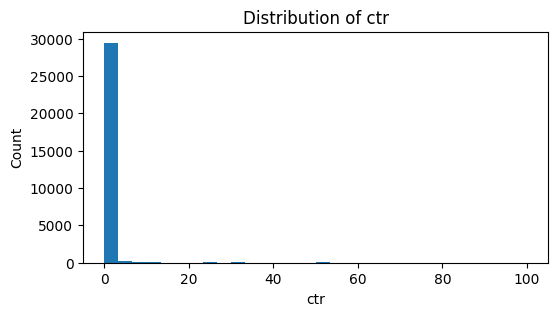

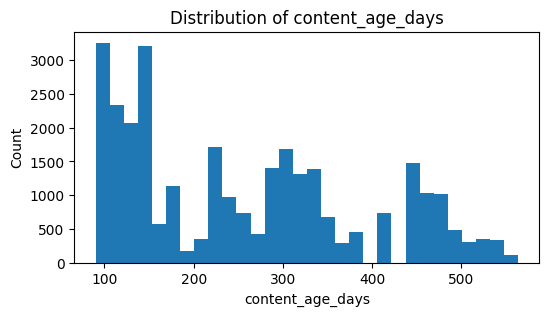

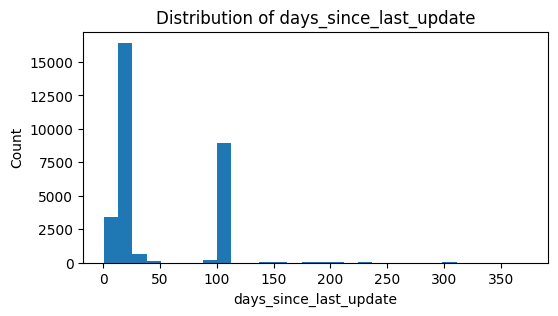

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("data/raw/content_refresh_anonymized.csv")

fields = [
    "impressions_90d",
    "ctr",
    "content_age_days",
    "days_since_last_update"
]

print(df[fields].describe())

for col in fields:
    plt.figure(figsize=(6,3))
    plt.hist(df[col].dropna(), bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

## 2. Signal test #1 / #2 / #3 (verdict each)

*Three safe signals, each with a mini-test and a verdict: CONFIRMED / OPPOSITE / MIXED / FALSE.*

## Signal Test #1

**Question:** Are older pages more likely to have declining performance?

**Verdict:** MIXED

Older pages appear across multiple trend categories, and the median content age varies only moderately between groups. In this dataset, declining pages are not the oldest, suggesting that page age alone is not a reliable indicator for deciding whether content should be refreshed.

In [19]:
median_age = df.groupby("trend_direction")["content_age_days"].median()

print(median_age.round(0))

trend_direction
down      216.0
flat      231.0
new       279.0
stable    300.0
up        292.0
Name: content_age_days, dtype: float64


## Signal Test #2

**Question:** Does click-through rate decrease as search position worsens?

**Verdict:** CONFIRMED

The average CTR generally decreases for lower ranking position tiers, supporting the expected relationship between search position and user clicks.

In [20]:
ctr_position = (
    df.groupby("position_tier")["ctr"]
      .mean()
      .sort_values(ascending=False)
)

print(ctr_position.round(3))

position_tier
top_3       1.484
page_1      0.652
striking    0.323
page_3_5    0.222
deep        0.150
Name: ctr, dtype: float64


## Signal Test #3

**Question:** Do pages with higher impressions always show better performance?

**Verdict: MIXED**

Stable pages have the highest median impressions, while declining pages also receive substantial visibility. This suggests that impression volume alone is not sufficient for deciding refresh priority and should be interpreted together with other search performance signals.

In [21]:
impressions = df.groupby("trend_direction")["impressions_90d"].median()

print(impressions.round(0))

trend_direction
down       961.0
flat         4.0
new          3.0
stable    1944.0
up         587.0
Name: impressions_90d, dtype: float64


## 3. The flag-linked test

*Pick a signal one of FlyRank's real flags relies on. Does the data support the rule's assumption?*

## The Flag-Linked Test

One of FlyRank's refresh signals is content staleness, represented by the number of days since the last update.

**Verdict: MIXED**

The median number of days since the last update is similar across trend categories. This suggests that content freshness alone is not enough to identify declining pages. It should be combined with other observable signals such as impressions, CTR, and average position when prioritizing content review.

In [22]:
stale = df.groupby("trend_direction")["days_since_last_update"].median()

print(stale.round(0))

trend_direction
down      20.0
flat      20.0
new       20.0
stable    22.0
up        22.0
Name: days_since_last_update, dtype: float64


## 4. What this means in practice

*Two or three sentences: what a content team should take from this.*



The signal audit shows that no single metric is sufficient for prioritizing content refreshes. Signals such as impressions, click-through rate, search position, and content freshness should be evaluated together.

These observations support using a multi-factor scoring rule or machine learning ranking approach for decision support rather than relying on one manually defined threshold. The results describe observed relationships and should not be interpreted as evidence of cause-and-effect.